# 04 - Train P2PNet for Dense Animal CountingThis notebook trains the P2PNet (Point-to-Point Network) model for dense herd counting and species classification.

## Objectives

1. Load tiles with point annotations from GCS
2. Train P2PNet with multi-class support (6 species)
3. Validate every epoch with counting metrics
4. **Early stopping** when validation plateaus
5. **Adaptive LR** based on validation performance
6. Save checkpoints to GCS7. Export final model for inference

## Model Architecture
- **Backbone**: VGG16-BN (pretrained on ImageNet)
- **Heads**: Point regression + Species classification + Confidence
- **Matching**: Hungarian algorithm (DETR-style)
- **Loss**: L1 point distance + Cross-entropy + BCE confidence

## Training Configuration (Optimized)
- **Max epochs**: 500 (with early stopping)
- **Early stopping**: Patience 50 epochs, min_delta 0.1
- **Batch size**: 8
- **Optimizer**: AdamW (lr=0.0001 for heads, lr_backbone=0.00001)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=20 epochs)
- **Hardware**: GPU required (A100/L4 recommended)
- **Storage**: Google Cloud Storage

## 1. Setup and Authentication

In [ ]:
from google.colab import auth
auth.authenticate_user()
print("User authenticated")

User authenticated


## 2. Install Dependencies

In [ ]:
%%bash
pip install -q \
    torch>=2.0.0 \
    torchvision>=0.15.0 \
    scipy>=1.10.0 \
    albumentations>=1.3.1 \
    opencv-python>=4.8.0 \
    pycocotools>=2.0.7 \
    tqdm>=4.66.0 \
    pyyaml>=6.0 \
    matplotlib>=3.7.0 \
    tensorboard>=2.13.0 \
    google-cloud-storage>=2.10.0

echo "Dependencies installed successfully"

Dependencies installed successfully


## 3. Download Util from GCS and Import p2pNet Modules

In [ ]:
# GCS Configuration
PROJECT_ID = "glass-genius-475202-s7"
BUCKET_NAME = "maia_animal_detection_v3"
BUCKET_URL = f"gs://{BUCKET_NAME}"

# Set GCP project
!gcloud config set project {PROJECT_ID}

# Download utils folder from GCS
print("Downloading utils from GCS...")
!gsutil -m cp -r {BUCKET_URL}/utils /content/

# Add to Python path
import sys
sys.path.insert(0, '/content')

print("Utils downloaded and added to path")

INFORMATION: Project 'glass-genius-475202-s7' has no 'environment' tag set. Use either 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`.
Updated property [core/project].
Copying gs://maia_animal_detection_v3/utils/__init__.py...
Copying gs://maia_animal_detection_v3/utils/__pycache__/__init__.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/__pycache__/config_loader.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/__pycache__/evaluation_utils.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/__pycache__/gcs_setup_helper.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/__pycache__/p2pnet_loss.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/__pycache__/p2pnet_matcher.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/__pycache__/tile_utils.cpython-312.pyc...
Copying gs://maia_animal_detection_v3/utils/config_loader.py...
Copying

In [ ]:
# Import P2PNet modules
from utils.p2pnet_model import build_p2pnet, count_parameters
from utils.p2pnet_matcher import build_matcher
from utils.p2pnet_loss import build_criterion
from utils.p2pnet_dataset import build_dataloader
from utils.metrics import compute_per_class_metrics, print_per_class_metrics

print("P2PNet modules imported successfully")

P2PNet modules imported successfully


## 4. Other Imports

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys
import yaml
import json
import time
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

print("Imports loaded")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Imports loaded
PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.80 GB


## 5. Configuration

In [ ]:
# ============================================================================
# TRAINING CONFIGURATION - Original P2PNet Architecture
# ============================================================================
config = {
    'model': {
        'backbone': 'vgg16_bn',
        'num_classes': 6,
        'num_queries': 700,
        'row': 2,
        'line': 2,
        'pretrained': True
    },
    'training': {
        'epochs': 500,
        'batch_size': 2,  # Reduced for 1536×1536 tiles (~12GB VRAM)
        'lr': 0.0001,
        'lr_backbone': 0.00001,
        'weight_decay': 0.0001,
        'num_workers': 4,
        'gradient_accumulation_steps': 4,  # Effective batch size = 8
        'use_mixed_precision': True,

        'early_stopping': {
            'patience': 15,
            'min_delta': 0.1
        },

        'lr_scheduler': {
            'type': 'ReduceLROnPlateau',
            'mode': 'min',
            'factor': 0.5,
            'patience': 5,
            'min_lr': 1e-7
        },

        # Original P2PNet loss weights from paper
        'loss_weights': {
            'point': 0.0002,      # Original P2PNet value
            'class': 1.0,         # Original P2PNet value
            'confidence': 0.05,   # Reduced from 0.5 - Original P2PNet value
            'eos_coef': 0.5       # Original P2PNet value
        },

        # Original P2PNet matcher costs from paper
        'matcher': {
            'cost_point': 0.05,   # Original P2PNet value
            'cost_class': 1.0,    # Original P2PNet value
            'cost_confidence': 1.0
        }
    },
    'data': {
        'tiles_root': '/content/tiles',
        'class_counts': [1678, 1058, 1732, 316, 166, 2012]  # alcelaphinae, buffalo, kob, warthog, waterbuck, elephant (COCO ID order)
    }
}


# ============================================================================
# PATHS AND LOGGING
# ============================================================================
from pathlib import Path

TILES_ROOT = Path(config['data']['tiles_root'])
CHECKPOINTS_DIR = Path('/content/checkpoints')
LOGS_DIR = Path('/content/logs')

# Create directories if they don't exist
CHECKPOINTS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

# ============================================================================
# PRINT CONFIGURATION SUMMARY
# ============================================================================
print("Configuration (Original P2PNet Architecture):")
print(f"  Epochs: {config['training']['epochs']}")
print(f"  Batch size: {config['training']['batch_size']} (effective: {config['training']['batch_size'] * config['training']['gradient_accumulation_steps']})")
print(f"  Early stopping patience: {config['training']['early_stopping']['patience']}")
print(f"  Learning rate: {config['training']['lr']}")
print(f"  Backbone LR: {config['training']['lr_backbone']}")
print(f"  LR scheduler patience: {config['training']['lr_scheduler']['patience']}")
print(f"\nLoss weights (from paper):")
print(f"  Point: {config['training']['loss_weights']['point']}")
print(f"  Class: {config['training']['loss_weights']['class']}")
print(f"  Confidence: {config['training']['loss_weights']['confidence']}")
print(f"  EOS coef: {config['training']['loss_weights']['eos_coef']}")
print(f"\nMatcher costs (from paper):")
print(f"  Point: {config['training']['matcher']['cost_point']}")
print(f"  Class: {config['training']['matcher']['cost_class']}")

Configuration (Original P2PNet Architecture):
  Epochs: 500
  Batch size: 2 (effective: 8)
  Early stopping patience: 15
  Learning rate: 0.0001
  Backbone LR: 1e-05
  LR scheduler patience: 5

Loss weights (from paper):
  Point: 0.0002
  Class: 1.0
  Confidence: 0.05
  EOS coef: 0.5

Matcher costs (from paper):
  Point: 0.05
  Class: 1.0


## 6. Download Data from GCS

In [ ]:
print("Downloading tiles and annotations from GCS...")
print(f"Source: {BUCKET_URL}/tiles/")
print("This will take 2-3 minutes...\n")

# Download tiles
!gsutil -m cp -r {BUCKET_URL}/tiles /content/

# Verify download
print("\nVerifying download...")

train_tiles = TILES_ROOT / 'train_1536_ov320'
val_tiles = TILES_ROOT / 'val_1536_ov320'
annotations = TILES_ROOT / 'annotations'

if train_tiles.exists() and val_tiles.exists() and annotations.exists():
    train_count = len(list(train_tiles.glob('*.jpg')))
    val_count = len(list(val_tiles.glob('*.jpg')))

    print(f"\nDownload successful:")
    print(f"  Train tiles (1536×1536): {train_count}")
    print(f"  Val tiles (1536×1536): {val_count}")
    print(f"  Annotations: {annotations}")
else:
    raise FileNotFoundError("Download failed. Check GCS bucket structure.")

Source: gs://maia_animal_detection_v3/tiles/
This will take 2-3 minutes...

Copying gs://maia_animal_detection_v3/tiles/annotations/test_tile_metadata.json...
Copying gs://maia_animal_detection_v3/tiles/annotations/test_tiles.json...
Copying gs://maia_animal_detection_v3/tiles/annotations/train_tile_metadata.json...
Copying gs://maia_animal_detection_v3/tiles/annotations/val_tile_metadata.json...
Copying gs://maia_animal_detection_v3/tiles/annotations/train_tiles.json...
Copying gs://maia_animal_detection_v3/tiles/annotations/val_tiles.json...
Copying gs://maia_animal_detection_v3/tiles/test_1536_ov320/018f5ab5b7516a47ff2ac48a9fc08353b533c30f_0_0.jpg...
Copying gs://maia_animal_detection_v3/tiles/test_1536_ov320/018f5ab5b7516a47ff2ac48a9fc08353b533c30f_0_1216.jpg...
Copying gs://maia_animal_detection_v3/tiles/test_1536_ov320/018f5ab5b7516a47ff2ac48a9fc08353b533c30f_1216_1216.jpg...
Copying gs://maia_animal_detection_v3/tiles/test_1536_ov320/018f5ab5b7516a47ff2ac48a9fc08353b533c30f_2432

## 7. Build Model, Matcher, and Criterion

In [ ]:
print("Building P2PNet model...")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Build model
model = build_p2pnet(config)
model = model.to(device)

# Build matcher
matcher = build_matcher(config)

# Build criterion
criterion = build_criterion(config, matcher)
criterion = criterion.to(device)

# Count parameters
num_params = count_parameters(model)

print(f"\nModel built successfully:")
print(f"  Backbone: VGG16-BN (pretrained)")
print(f"  Total parameters: {num_params:,}")
print(f"  Number of classes: {config['model']['num_classes']}")
print(f"  Max predictions per image: {config['model']['num_queries']}")

Building P2PNet model...
Device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✓ Class-weighted loss enabled (balanced hierarchy)
  Class counts: [1678, 1058, 1732, 316, 166, 2012]
  Clamp range: min=0.8×, max=2.5×
  Class weights: ['0.80', '1.10', '0.80', '2.50', '2.50', '0.80']

Model built successfully:
  Backbone: VGG16-BN (pretrained)
  Total parameters: 16,718,052
  Number of classes: 6
  Max predictions per image: 700


## 8. Build Dataloaders

In [ ]:
print("Building dataloaders...")

# Training dataloader
train_loader = build_dataloader(
    tiles_dir=str(TILES_ROOT / 'train_1536_ov320'),
    annotation_file=str(TILES_ROOT / 'annotations' / 'train_tiles.json'),
    batch_size=config['training']['batch_size'],
    num_workers=config['training']['num_workers'],
    shuffle=True,
    augment=True  # CLAHE disabled in p2pnet_dataset.py
)

# Validation dataloader
val_loader = build_dataloader(
    tiles_dir=str(TILES_ROOT / 'val_1536_ov320'),
    annotation_file=str(TILES_ROOT / 'annotations' / 'val_tiles.json'),
    batch_size=config['training']['batch_size'],
    num_workers=config['training']['num_workers'],
    shuffle=False,
    augment=False
)

print(f"\nDataloaders built:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Batch size: {config['training']['batch_size']} (effective: {config['training']['batch_size'] * config['training']['gradient_accumulation_steps']})")
print(f"  Workers: {config['training']['num_workers']}")

Building dataloaders...
Loaded dataset with 2698 images and 9469 points
Classes: 6 | COCO ids -> indices: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
✓ Uniform weighted sampling enabled (balanced strategy)
  All animal tiles: 2× sampling rate
  Empty tiles: 1× sampling rate
Loaded dataset with 371 images and 1334 points
Classes: 6 | COCO ids -> indices: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}

Dataloaders built:
  Train batches: 1349
  Val batches: 186
  Batch size: 2 (effective: 8)
  Workers: 4


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 9. Setup Optimizer and Scheduler

In [ ]:
# ============================================================================
# OPTIMIZER AND SCHEDULER SETUP
# ============================================================================

print("Setting up optimizer and scheduler...")

# ----------------------------------------------------------------------------
# Separate backbone and head parameters for different learning rates
# ----------------------------------------------------------------------------
param_dicts = [
    {
        "params": [
            p for n, p in model.named_parameters()
            if "backbone" not in n and p.requires_grad
        ]
    },
    {
        "params": [
            p for n, p in model.named_parameters()
            if "backbone" in n and p.requires_grad
        ],
        "lr": config['training']['lr_backbone'],
    },
]

# ----------------------------------------------------------------------------
# AdamW optimizer
# ----------------------------------------------------------------------------
optimizer = torch.optim.AdamW(
    param_dicts,
    lr=config['training']['lr'],
    weight_decay=config['training']['weight_decay']
)

# ----------------------------------------------------------------------------
# ReduceLROnPlateau scheduler
# Adapts the learning rate based on validation MAE improvements
# ----------------------------------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=config['training']['lr_scheduler']['mode'],
    factor=config['training']['lr_scheduler']['factor'],
    patience=config['training']['lr_scheduler']['patience'],
    min_lr=config['training']['lr_scheduler']['min_lr']
)

# ----------------------------------------------------------------------------
# Print summary
# ----------------------------------------------------------------------------
print("Optimizer: AdamW")
print(f"  Head LR: {config['training']['lr']}")
print(f"  Backbone LR: {config['training']['lr_backbone']}")
print(f"  Weight decay: {config['training']['weight_decay']}")

print("\nScheduler: ReduceLROnPlateau")
print(f"  Mode: {config['training']['lr_scheduler']['mode']}")
print(f"  Factor: {config['training']['lr_scheduler']['factor']}")
print(f"  Patience: {config['training']['lr_scheduler']['patience']} epochs")
print(f"  Min LR: {config['training']['lr_scheduler']['min_lr']}")

print("\nEarly Stopping:")
print(f"  Patience: {config['training']['early_stopping']['patience']} epochs")
print(f"  Min delta: {config['training']['early_stopping']['min_delta']}")

Setting up optimizer and scheduler...
Optimizer: AdamW
  Head LR: 0.0001
  Backbone LR: 1e-05
  Weight decay: 0.0001

Scheduler: ReduceLROnPlateau
  Mode: min
  Factor: 0.5
  Patience: 5 epochs
  Min LR: 1e-07

Early Stopping:
  Patience: 15 epochs
  Min delta: 0.1


## 10. Training Functions

In [ ]:
# ============================================================================
# TRAIN / VAL / CKPT / GCS HELPERS
# ============================================================================

def train_one_epoch(model, criterion, dataloader, optimizer, device, epoch, writer, config, scaler=None):
    """
    Train for one epoch with gradient accumulation and mixed precision.
    """
    model.train()
    criterion.train()

    epoch_loss = 0
    epoch_loss_point = 0
    epoch_loss_class = 0
    epoch_loss_conf = 0

    # Gradient accumulation settings
    accumulation_steps = config['training'].get('gradient_accumulation_steps', 1)
    use_amp = config['training'].get('use_mixed_precision', False)

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}")
    optimizer.zero_grad()  # Zero gradients at start

    for batch_idx, (images, targets) in enumerate(progress_bar):
        # Move to device
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                   for k, v in t.items()} for t in targets]

        # Mixed precision forward pass
        if use_amp and scaler is not None:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss_dict = criterion(outputs, targets)
                loss = loss_dict['loss'] / accumulation_steps  # Scale loss for accumulation
        else:
            outputs = model(images)
            loss_dict = criterion(outputs, targets)
            loss = loss_dict['loss'] / accumulation_steps

        # Backward pass with mixed precision
        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        # Accumulate losses (unscaled for logging)
        epoch_loss += loss_dict['loss'].item()
        epoch_loss_point += loss_dict['loss_point'].item()
        epoch_loss_class += loss_dict['loss_class'].item()
        epoch_loss_conf += loss_dict['loss_confidence'].item()

        # Update weights after accumulation_steps
        if (batch_idx + 1) % accumulation_steps == 0:
            # Gradient clipping
            if use_amp and scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
                optimizer.step()

            optimizer.zero_grad()

        # Update progress bar
        progress_bar.set_postfix({
            'loss': f"{loss_dict['loss'].item():.4f}",
            'pt': f"{loss_dict['loss_point'].item():.4f}",
            'cls': f"{loss_dict['loss_class'].item():.4f}",
            'conf': f"{loss_dict['loss_confidence'].item():.4f}"
        })

        # Log to tensorboard every 100 batches
        if batch_idx % 100 == 0:
            global_step = epoch * len(dataloader) + batch_idx
            writer.add_scalar('train/loss', loss_dict['loss'].item(), global_step)
            writer.add_scalar('train/loss_point', loss_dict['loss_point'].item(), global_step)
            writer.add_scalar('train/loss_class', loss_dict['loss_class'].item(), global_step)
            writer.add_scalar('train/loss_conf', loss_dict['loss_confidence'].item(), global_step)

    # Average losses
    num_batches = len(dataloader)
    return {
        'loss': epoch_loss / num_batches,
        'loss_point': epoch_loss_point / num_batches,
        'loss_class': epoch_loss_class / num_batches,
        'loss_conf': epoch_loss_conf / num_batches
    }

@torch.no_grad()
def validate(model, criterion, dataloader, device, epoch, writer, config):
    """
    Validate model with per-class metrics tracking.
    """
    model.eval()
    criterion.eval()

    epoch_loss = 0
    epoch_mae = 0  # Mean Absolute Error for counting

    # Collect predictions and targets for per-class metrics
    all_predictions = []
    all_targets = []

    for images, targets in tqdm(dataloader, desc="Validation"):
        # Move to device
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                   for k, v in t.items()} for t in targets]

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss_dict = criterion(outputs, targets)
        epoch_loss += loss_dict['loss'].item()

        # Compute counting MAE
        # NOTE: pred_scores are now logits, apply sigmoid to get probabilities
        pred_logits = outputs['pred_scores']  # [B, num_queries] - logits
        pred_scores = torch.sigmoid(pred_logits)  # Convert to probabilities

        for i, target in enumerate(targets):
            # Count predictions above threshold
            pred_count = (pred_scores[i] > 0.5).sum().item()
            gt_count = len(target['points'])
            epoch_mae += abs(pred_count - gt_count)

            # Collect for per-class metrics
            all_predictions.append({
                'pred_points': outputs['pred_points'][i],
                'pred_logits': outputs['pred_logits'][i],
                'pred_scores': outputs['pred_scores'][i]
            })
            all_targets.append(target)

    # Average metrics
    num_batches = len(dataloader)
    num_images = len(dataloader.dataset)

    avg_loss = epoch_loss / num_batches
    avg_mae = epoch_mae / num_images

    # Compute per-class metrics
    class_names = ['alcelaphinae', 'buffalo', 'kob', 'warthog', 'waterbuck', 'elephant']

    # Compute actual validation counts from targets
    import numpy as np
    val_class_counts = np.zeros(config['model']['num_classes'], dtype=int)
    for target in all_targets:
        for label in target['labels'].cpu().numpy():
            val_class_counts[label] += 1
    val_class_counts = val_class_counts.tolist()

    per_class_metrics = compute_per_class_metrics(
        predictions=all_predictions,
        targets=all_targets,
        num_classes=config['model']['num_classes'],
        class_names=class_names,
        distance_threshold=10.0,
        confidence_threshold=0.5
    )

    # Print per-class metrics
    print_per_class_metrics(per_class_metrics, val_class_counts)

    # Log to tensorboard
    writer.add_scalar('val/loss', avg_loss, epoch)
    writer.add_scalar('val/mae', avg_mae, epoch)

    # Log per-class metrics to tensorboard
    for i, name in enumerate(class_names):
        writer.add_scalar(f'val/precision_{name}', per_class_metrics['precision'][i], epoch)
        writer.add_scalar(f'val/recall_{name}', per_class_metrics['recall'][i], epoch)
        writer.add_scalar(f'val/f1_{name}', per_class_metrics['f1'][i], epoch)

    # Log macro averages
    writer.add_scalar('val/macro_precision', per_class_metrics['macro_precision'], epoch)
    writer.add_scalar('val/macro_recall', per_class_metrics['macro_recall'], epoch)
    writer.add_scalar('val/macro_f1', per_class_metrics['macro_f1'], epoch)

    return {
        'loss': avg_loss,
        'mae': avg_mae,
        'per_class_metrics': per_class_metrics
    }


def save_checkpoint(model, optimizer, scheduler, epoch, checkpoint_dir, val_mae=None, best_val_mae=None, is_best=False):
    """
    Save checkpoint - only best.pt and last.pt (no epoch checkpoints).
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }

    # Add MAE metrics if provided
    if val_mae is not None:
        checkpoint['val_mae'] = val_mae
    if best_val_mae is not None:
        checkpoint['best_val_mae'] = best_val_mae

    # Save last checkpoint
    torch.save(checkpoint, checkpoint_dir / 'last.pt')

    # Save best checkpoint
    if is_best:
        torch.save(checkpoint, checkpoint_dir / 'best.pt')

def upload_to_gcs(local_path, gcs_path):
    """
    Upload file to GCS.
    """
    import subprocess
    try:
        result = subprocess.run(
            ['gsutil', 'cp', str(local_path), gcs_path],
            capture_output=True,
            text=True
        )
        return result.returncode == 0
    except Exception as e:
        print(f"Upload failed: {e}")
        return False

print("Training functions defined")

Training functions defined


## 10.1. Recovery from Checkpoint (Optional - Run if Colab Crashed)

In [ ]:
# ============================================================================
# COLAB BEST CHECKPOINT FINDER
# ONLY RUN THIS CELL TO RESUME TRAINING IF COLAB CRASHES
# Otherwise skip to the next cell
# ============================================================================

# import torch
# from pathlib import Path

# CHECKPOINT_PATH = CHECKPOINTS_DIR / 'last.pt'  # or 'best.pt'

# if CHECKPOINT_PATH.exists():
#     print(f"Loading checkpoint from {CHECKPOINT_PATH}...")

#     checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

#     # Load model state
#     model.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

#     start_epoch = checkpoint['epoch'] + 1

#     print(f"✓ Checkpoint loaded successfully")
#     print(f"  Resuming from epoch: {start_epoch}")
#     print(f"  Current LR: {optimizer.param_groups[0]['lr']:.6f}")

#     # Update config to start from this epoch
#     config['training']['start_epoch'] = start_epoch
# else:
#     print(f"Checkpoint not found at {CHECKPOINT_PATH}")
#     print("Available checkpoints:")
#     for ckpt in CHECKPOINTS_DIR.glob('*.pt'):
#         print(f"  - {ckpt.name}")

## 10.2. Recovery from Best Checkpoint Stored in GCS

**Recovery process if runtime crashes:**

**Step 1:** Run GCS Global Best Checkpoint Finder (Cell below)
- Uncomment and run.
- It searches all GCS checkpoint folders and finds the best one by MAE.
- Output shows the best checkpoint location and commands.

**Step 2 is two cells below...**

In [ ]:
# ============================================================================
# GCS GLOBAL BEST CHECKPOINT FINDER
# Searches all checkpoint folders and finds the one with the lowest val_mae
# ============================================================================

# import subprocess
# import torch
# from pathlib import Path
# import tempfile
# import shutil

# BUCKET_URL = "gs://maia_animal_detection_v3"
# CHECKPOINT_BASE = f"{BUCKET_URL}/checkpoints/p2pnet/"

# print("=" * 70)
# print("SEARCHING FOR BEST CHECKPOINT ACROSS ALL FOLDERS")
# print("=" * 70)

# # List all timestamp folders
# print("\nListing all checkpoint folders in GCS...")
# result = subprocess.run(
#     ['gsutil', 'ls', CHECKPOINT_BASE],
#     capture_output=True,
#     text=True
# )

# if result.returncode != 0:
#     print(f"Error listing GCS folders: {result.stderr}")
#     exit(1)

# timestamp_folders = [line.strip() for line in result.stdout.strip().split('\n') if line.strip()]
# print(f"Found {len(timestamp_folders)} checkpoint folders\n")

# # Create temp directory
# temp_dir = Path(tempfile.mkdtemp())
# print(f"Using temp directory: {temp_dir}\n")

# # Search through each folder
# all_checkpoints = []

# for i, folder in enumerate(timestamp_folders, 1):
#     timestamp = folder.rstrip('/').split('/')[-1]
#     best_pt_path = f"{folder}best.pt"
#     temp_file = temp_dir / f"{timestamp}_best.pt"

#     print(f"[{i}/{len(timestamp_folders)}] Checking {timestamp}...", end=" ")

#     # Check if best.pt exists
#     check_result = subprocess.run(
#         ['gsutil', 'ls', best_pt_path],
#         capture_output=True,
#         text=True
#     )

#     if check_result.returncode != 0:
#         print("No best.pt")
#         continue

#     # Download checkpoint
#     download_result = subprocess.run(
#         ['gsutil', 'cp', best_pt_path, str(temp_file)],
#         capture_output=True,
#         text=True
#     )

#     if download_result.returncode != 0:
#         print("Download failed")
#         continue

#     try:
#         # Load checkpoint to get metrics
#         checkpoint = torch.load(temp_file, map_location='cpu')
#         epoch = checkpoint.get('epoch', 'unknown')
#         val_mae = checkpoint.get('val_mae', checkpoint.get('best_val_mae', None))

#         if val_mae is not None:
#             all_checkpoints.append({
#                 'timestamp': timestamp,
#                 'folder': folder,
#                 'epoch': epoch,
#                 'val_mae': float(val_mae)
#             })
#             print(f"✓ Epoch {epoch}, MAE: {val_mae:.2f}")
#         else:
#             print(f"✓ Epoch {epoch}, MAE: N/A")

#         # Clean up
#         temp_file.unlink()

#     except Exception as e:
#         print(f"Error: {e}")

# # Clean up temp directory
# shutil.rmtree(temp_dir)

# print("\n" + "=" * 70)

# if len(all_checkpoints) > 0:
#     # Sort by MAE (ascending)
#     all_checkpoints.sort(key=lambda x: x['val_mae'])

#     best = all_checkpoints[0]

#     print("GLOBAL BEST CHECKPOINT FOUND!")
#     print("=" * 70)
#     print(f"\nTimestamp: {best['timestamp']}")
#     print(f"Epoch: {best['epoch']}")
#     print(f"Val MAE: {best['val_mae']:.2f}")
#     print(f"Folder: {best['folder']}")

#     print("\n" + "=" * 70)
#     print("ALL CHECKPOINTS (sorted by MAE):")
#     print("=" * 70)
#     for i, ckpt in enumerate(all_checkpoints[:10], 1):  # Top 10
#         print(f"{i}. {ckpt['timestamp']}: Epoch {ckpt['epoch']}, MAE {ckpt['val_mae']:.2f}")
#     if len(all_checkpoints) > 10:
#         print(f"... and {len(all_checkpoints) - 10} more")

#     print("\n" + "=" * 70)
#     print("TO LOAD THIS CHECKPOINT:")
#     print("=" * 70)
#     print(f"\n# Download")
#     print(f"!gsutil cp {best['folder']}best.pt /content/checkpoints/global_best.pt")
#     print(f"\n# Load")
#     print(f"checkpoint = torch.load('/content/checkpoints/global_best.pt', map_location=device)")
#     print(f"model.load_state_dict(checkpoint['model_state_dict'])")
#     print(f"optimizer.load_state_dict(checkpoint['optimizer_state_dict'])")
#     print(f"scheduler.load_state_dict(checkpoint['scheduler_state_dict'])")
#     print(f"config['training']['start_epoch'] = {best['epoch']} + 1")
#     print("\n" + "=" * 70)
# else:
#     print("NO CHECKPOINTS WITH VAL_MAE FOUND")
#     print("=" * 70)
#     print("\nThis might mean:")
#     print("  - No checkpoints have been saved yet")
#     print("  - Checkpoints were saved before val_mae was added to save_checkpoint()")
#     print("\n" + "=" * 70)

**Step 2:** Follow the output commands

The finder will print the information required for the following cell:

- Timestamp: 20250113_143022
- Epoch: 14
- Val MAE: 5.11
- Folder: gs://maia_animal_detection_v3/checkpoints/p2pnet/20250113_143022/

**Step 3:** Run the following commands:

In [ ]:
# # Load
# BEST_PT = "best.pt" # This is the best.pt name in GCS
# BEST_PT_EPOCH = 15 # This is the best.pt epoch
# BEST_PT_GCS_DIR = "20250113_143022" # This is the GCS folder

# # Download
# !gsutil cp gs://maia_animal_detection_v3/checkpoints/p2pnet/{BEST_PT_GCS_DIR}/best.pt /content/checkpoints/global_best.pt

# checkpoint = torch.load(f'/content/checkpoints/{BEST_PT}', map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
# config['training']['start_epoch'] = BEST_PT_EPOCH + 1

## 11. Training Loop

In [ ]:
# ============================================================================
# TRAINING FROM SCRATCH - Original P2PNet Architecture
# DO NOT run this cell if starting from a checkpoint
# ============================================================================

print("=" * 70)
print("TRAINING FROM SCRATCH - ORIGINAL P2PNET ARCHITECTURE")
print("=" * 70)
print("\n✓ Model: Fresh VGG16-BN (ImageNet pretrained)")
print("✓ Optimizer: Fresh AdamW")
print("✓ Scheduler: Fresh ReduceLROnPlateau")
print("\nArchitecture:")
print("  • Tile size: 1536×1536 (up from 1024×1024)")
print("  • Overlap: 320px (2× max animal size of 160px)")
print("  • Batch size: 2 (effective: 8 with gradient accumulation)")
print("\nData Pipeline:")
print("  ✓ Weighted sampling: 3× oversampling tiles with animals")
print("  ✓ Original augmentations: Geometric + Color transforms")
print("  ✗ CLAHE: Disabled (not in original P2PNet)")
print("\nLoss Configuration (from paper):")
print(f"  • λ_point: {config['training']['loss_weights']['point']}")
print(f"  • λ_class: {config['training']['loss_weights']['class']}")
print(f"  • λ_confidence: {config['training']['loss_weights']['confidence']}")
print(f"  • eos_coef: {config['training']['loss_weights']['eos_coef']}")
print("\nMatcher Configuration (from paper):")
print(f"  • cost_point: {config['training']['matcher']['cost_point']}")
print(f"  • cost_class: {config['training']['matcher']['cost_class']}")
print("\n" + "=" * 70)
print("EXPECTED: Stable training with balanced losses")
print("TARGET: MAE < 2.5 within 40-60 epochs")
print("=" * 70)

# Ensure we start from epoch 1
config['training']['start_epoch'] = 1

TRAINING FROM SCRATCH - ORIGINAL P2PNET ARCHITECTURE

✓ Model: Fresh VGG16-BN (ImageNet pretrained)
✓ Optimizer: Fresh AdamW
✓ Scheduler: Fresh ReduceLROnPlateau

Architecture:
  • Tile size: 1536×1536 (up from 1024×1024)
  • Overlap: 320px (2× max animal size of 160px)
  • Batch size: 2 (effective: 8 with gradient accumulation)

Data Pipeline:
  ✓ Weighted sampling: 3× oversampling tiles with animals
  ✓ Original augmentations: Geometric + Color transforms
  ✗ CLAHE: Disabled (not in original P2PNet)

Loss Configuration (from paper):
  • λ_point: 0.0002
  • λ_class: 1.0
  • λ_confidence: 0.05
  • eos_coef: 0.5

Matcher Configuration (from paper):
  • cost_point: 0.05
  • cost_class: 1.0

EXPECTED: Stable training with balanced losses
TARGET: MAE < 2.5 within 40-60 epochs


In [ ]:
print("="*70)
print("STARTING TRAINING")
print("="*70)

# Initialize tensorboard
writer = SummaryWriter(log_dir=str(LOGS_DIR))

# Initialize mixed precision scaler
use_amp = config['training'].get('use_mixed_precision', False)
scaler = torch.amp.GradScaler('cuda') if use_amp else None

if use_amp:
    print("✓ Mixed precision training enabled (AMP)")

if config['training'].get('gradient_accumulation_steps', 1) > 1:
    print(f"✓ Gradient accumulation enabled ({config['training']['gradient_accumulation_steps']} steps)")
    print(f"  Effective batch size: {config['training']['batch_size'] * config['training']['gradient_accumulation_steps']}")

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],
    'lr': []
}

# Early stopping variables
best_mae = float('inf')
best_epoch = 0
epochs_without_improvement = 0
patience = config['training']['early_stopping']['patience']
min_delta = config['training']['early_stopping']['min_delta']

start_time = time.time()
last_checkpoint_time = start_time

# Training loop
start_epoch = config['training'].get('start_epoch', 1)  # Support recovery

for epoch in range(start_epoch, config['training']['epochs'] + 1):
    # Free unused memory at start of each epoch
    torch.cuda.empty_cache()

    print(f"\n{'='*70}")
    print(f"Epoch {epoch}/{config['training']['epochs']}")
    print(f"{'='*70}")

    # Train
    train_metrics = train_one_epoch(
        model, criterion, train_loader, optimizer, device, epoch, writer, config, scaler
    )

    # Validate
    val_metrics = validate(
        model, criterion, val_loader, device, epoch, writer, config
    )

    # Update scheduler based on validation MAE
    scheduler.step(val_metrics['mae'])

    # Log metrics
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_mae'].append(val_metrics['mae'])
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Print summary
    print(f"\nEpoch {epoch} Summary:")
    print(f"  Train Loss: {train_metrics['loss']:.4f}")
    print(f"    - Point: {train_metrics['loss_point']:.4f}")
    print(f"    - Class: {train_metrics['loss_class']:.4f}")
    print(f"    - Conf: {train_metrics['loss_conf']:.4f}")
    print(f"  Val Loss: {val_metrics['loss']:.4f}")
    print(f"  Val MAE: {val_metrics['mae']:.2f}")
    print(f"  LR (head): {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  LR (backbone): {optimizer.param_groups[1]['lr']:.6f}")

    # Check if best model
    current_mae = val_metrics['mae']
    is_best = current_mae < (best_mae - min_delta)

    if is_best:
        best_mae = current_mae
        best_epoch = epoch
        epochs_without_improvement = 0
        print(f"  ✓ New best MAE: {best_mae:.2f}")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement ({epochs_without_improvement}/{patience})")

    # Save checkpoint (only on improvement to save space)
    if is_best:
        save_checkpoint(
            model, optimizer, scheduler, epoch, CHECKPOINTS_DIR,
            val_mae=current_mae,
            best_val_mae=best_mae,
            is_best=True
        )

    # Always save last checkpoint
    save_checkpoint(
        model, optimizer, scheduler, epoch, CHECKPOINTS_DIR,
        val_mae=current_mae,
        best_val_mae=best_mae,
        is_best=False
    )

    # Upload to GCS every 30 minutes
    current_time = time.time()
    if current_time - last_checkpoint_time > 1800:  # 30 minutes
        print("\n[GCS Backup] Uploading checkpoint...")
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gcs_checkpoint_path = f"{BUCKET_URL}/checkpoints/p2pnet/{timestamp}/"

        upload_to_gcs(
            CHECKPOINTS_DIR / 'last.pt',
            f"{gcs_checkpoint_path}last.pt"
        )
        upload_to_gcs(
            CHECKPOINTS_DIR / 'best.pt',
            f"{gcs_checkpoint_path}best.pt"
        )

        last_checkpoint_time = current_time
        print("[GCS Backup] Checkpoint uploaded")

    # Estimate time remaining
    elapsed = current_time - start_time
    avg_epoch_time = elapsed / epoch
    remaining_epochs = config['training']['epochs'] - epoch
    eta_seconds = avg_epoch_time * remaining_epochs
    eta_hours = eta_seconds / 3600

    print(f"  ETA (if no early stop): {eta_hours:.1f} hours")

    # Early stopping check
    if epochs_without_improvement >= patience:
        print(f"\n{'='*70}")
        print("EARLY STOPPING TRIGGERED")
        print(f"{'='*70}")
        print(f"No improvement for {patience} epochs")
        print(f"Best Val MAE: {best_mae:.2f} (epoch {best_epoch})")
        break

# Training complete
total_time = time.time() - start_time
total_epochs = epoch

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total epochs: {total_epochs}")
print(f"Total time: {total_time/3600:.2f} hours")
print(f"Best Val MAE: {best_mae:.2f} (epoch {best_epoch})")
print(f"Final LR: {optimizer.param_groups[0]['lr']:.6f}")

if use_amp:
    print(f"Mixed precision: Enabled")

print(f"Gradient accumulation: {config['training'].get('gradient_accumulation_steps', 1)} steps")

writer.close()

STARTING TRAINING
✓ Mixed precision training enabled (AMP)
✓ Gradient accumulation enabled (4 steps)
  Effective batch size: 8

Epoch 1/500


Validation: 100%|██████████| 186/186 [00:58<00:00,  3.16it/s]



PER-CLASS METRICS
Class            Count     TP     FP     FN    Prec     Rec      F1
--------------------------------------------------------------------------------
alcelaphinae       491      2     20    489   0.091   0.004   0.008
buffalo            151      0      0    151   0.000   0.000   0.000
kob                229    219   9178     10   0.023   0.956   0.046
warthog             54      3   1112     51   0.003   0.056   0.005
waterbuck           55      0      0     55   0.000   0.000   0.000
elephant           354      0     20    354   0.000   0.000   0.000
--------------------------------------------------------------------------------
Macro Avg                                     0.019   0.169   0.010
Micro Avg                                     0.021   0.168   0.038


Epoch 1 Summary:
  Train Loss: 411.7203
    - Point: 0.7861
    - Class: 1.8104
    - Conf: 8198.1951
  Val Loss: 57.3578
  Val MAE: 25.14
  LR (head): 0.000100
  LR (backbone): 0.000010
  ✓ New best MAE: 

Validation: 100%|██████████| 186/186 [00:58<00:00,  3.16it/s]



PER-CLASS METRICS
Class            Count     TP     FP     FN    Prec     Rec      F1
--------------------------------------------------------------------------------
alcelaphinae       491      2    144    489   0.014   0.004   0.006
buffalo            151      0      0    151   0.000   0.000   0.000
kob                229    153   2584     76   0.056   0.668   0.103
warthog             54      0      0     54   0.000   0.000   0.000
waterbuck           55      0      0     55   0.000   0.000   0.000
elephant           354     66   1164    288   0.054   0.186   0.083
--------------------------------------------------------------------------------
Macro Avg                                     0.021   0.143   0.032
Micro Avg                                     0.054   0.166   0.081


Epoch 2 Summary:
  Train Loss: 42.9904
    - Point: 0.9424
    - Class: 1.7595
    - Conf: 824.6145
  Val Loss: 27.7109
  Val MAE: 7.80
  LR (head): 0.000100
  LR (backbone): 0.000010
  ✓ New best MAE: 7.8

...


PER-CLASS METRICS
Class            Count     TP     FP     FN    Prec     Rec      F1
--------------------------------------------------------------------------------
alcelaphinae       491     78    306    413   0.203   0.159   0.178
buffalo            151      0      0    151   0.000   0.000   0.000
kob                229     57    557    172   0.093   0.249   0.135
warthog             54      0      2     54   0.000   0.000   0.000
waterbuck           55      0      0     55   0.000   0.000   0.000
elephant           354    316   2208     38   0.125   0.893   0.220
--------------------------------------------------------------------------------
Macro Avg                                     0.070   0.217   0.089
Micro Avg                                     0.128   0.338   0.186


Epoch 42 Summary:
  Train Loss: 24.7289
    - Point: 0.9242
    - Class: 1.5445
    - Conf: 463.6853
  Val Loss: 43.7348
  Val MAE: 6.35
  LR (head): 0.000003
  LR (backbone): 0.000000
  No improvement (13

Validation: 100%|██████████| 186/186 [00:59<00:00,  3.14it/s]



PER-CLASS METRICS
Class            Count     TP     FP     FN    Prec     Rec      F1
--------------------------------------------------------------------------------
alcelaphinae       491     89    363    402   0.197   0.181   0.189
buffalo            151      0      0    151   0.000   0.000   0.000
kob                229     94    837    135   0.101   0.410   0.162
warthog             54      2      4     52   0.333   0.037   0.067
waterbuck           55      0      0     55   0.000   0.000   0.000
elephant           354    306   1678     48   0.154   0.864   0.262
--------------------------------------------------------------------------------
Macro Avg                                     0.131   0.249   0.113
Micro Avg                                     0.146   0.368   0.209


Epoch 43 Summary:
  Train Loss: 26.6067
    - Point: 0.9237
    - Class: 1.5744
    - Conf: 500.6422
  Val Loss: 52.9541
  Val MAE: 6.03
  LR (head): 0.000003
  LR (backbone): 0.000000
  No improvement (14

Validation: 100%|██████████| 186/186 [00:59<00:00,  3.15it/s]



PER-CLASS METRICS
Class            Count     TP     FP     FN    Prec     Rec      F1
--------------------------------------------------------------------------------
alcelaphinae       491    111    434    380   0.204   0.226   0.214
buffalo            151      0      0    151   0.000   0.000   0.000
kob                229     88    748    141   0.105   0.384   0.165
warthog             54      2      5     52   0.286   0.037   0.066
waterbuck           55      0      0     55   0.000   0.000   0.000
elephant           354    223   1095    131   0.169   0.630   0.267
--------------------------------------------------------------------------------
Macro Avg                                     0.127   0.213   0.119
Micro Avg                                     0.157   0.318   0.210


Epoch 44 Summary:
  Train Loss: 28.2412
    - Point: 0.9264
    - Class: 1.5283
    - Conf: 534.2542
  Val Loss: 113.1034
  Val MAE: 4.60
  LR (head): 0.000003
  LR (backbone): 0.000000
  No improvement (1

## 12. Upload Final Model to GCS

In [ ]:
print("Uploading final model to GCS...")

# Upload checkpoints
!gsutil cp {CHECKPOINTS_DIR}/best.pt {BUCKET_URL}/models/p2pnet/best.pt
!gsutil cp {CHECKPOINTS_DIR}/last.pt {BUCKET_URL}/models/p2pnet/last.pt

# Upload training logs
!gsutil -m cp -r {LOGS_DIR} {BUCKET_URL}/logs/p2pnet/

# Save configuration
config_path = CHECKPOINTS_DIR / 'config.yaml'
with open(config_path, 'w') as f:
    yaml.dump(config, f)
!gsutil cp {config_path} {BUCKET_URL}/models/p2pnet/config.yaml

print("\nUpload complete:")
print(f"  Best model: {BUCKET_URL}/models/p2pnet/best.pt")
print(f"  Last model: {BUCKET_URL}/models/p2pnet/last.pt")
print(f"  Config: {BUCKET_URL}/models/p2pnet/config.yaml")
print(f"  Logs: {BUCKET_URL}/logs/p2pnet/")

Uploading final model to GCS...
Copying file:///content/checkpoints/best.pt [Content-Type=application/vnd.snesdev-page-table]...
==> NOTE: You are uploading one or more large file(s), which would run
significantly faster if you enable parallel composite uploads. This
feature can be enabled by editing the
"parallel_composite_upload_threshold" value in your .boto
configuration file. However, note that if you do this large files will
be uploaded as `composite objects
<https://cloud.google.com/storage/docs/composite-objects>`_,which
means that any user who downloads such objects will need to have a
compiled crcmod installed (see "gsutil help crcmod"). This is because
without a compiled crcmod, computing checksums on composite objects is
so slow that gsutil disables downloads of composite objects.

/ [1 files][191.4 MiB/191.4 MiB]   18.2 MiB/s                                   
Operation completed over 1 objects/191.4 MiB.                                    
Copying file:///content/checkpoi

## 13. Plot Training Curves

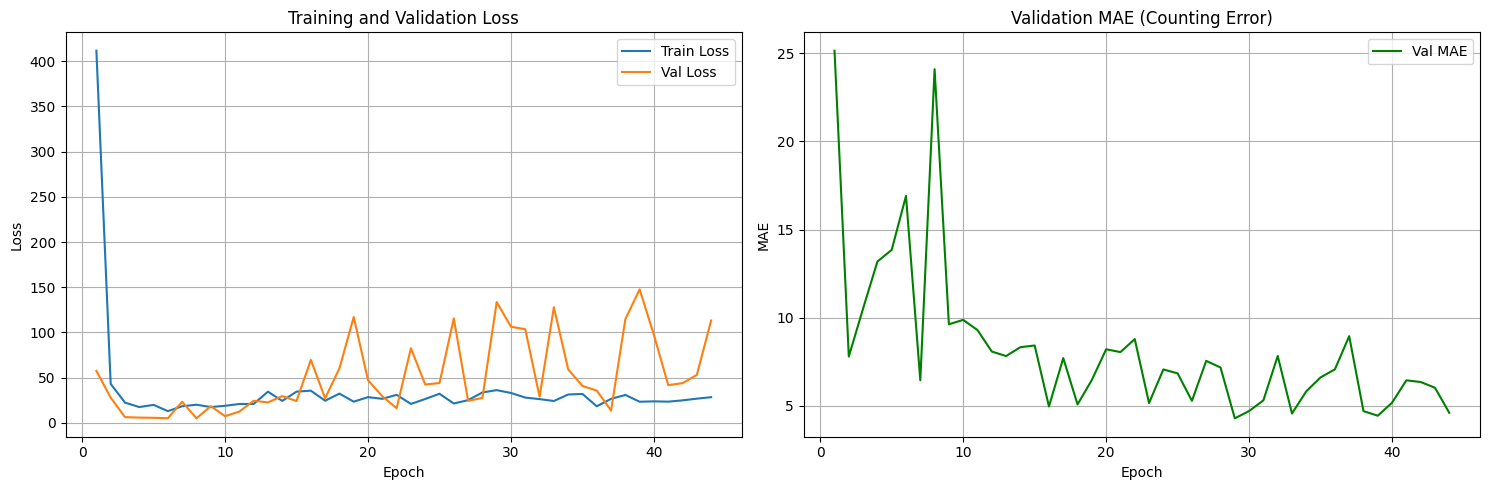

Copying file:///content/checkpoints/training_curves.png [Content-Type=image/png]...
-
Operation completed over 1 objects/122.6 KiB.                                    
Training curves saved


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# MAE curve
ax2.plot(epochs_range, history['val_mae'], label='Val MAE', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Validation MAE (Counting Error)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(CHECKPOINTS_DIR / 'training_curves.png', dpi=150)
plt.show()

# Upload plot to GCS
!gsutil cp {CHECKPOINTS_DIR}/training_curves.png {BUCKET_URL}/models/p2pnet/training_curves.png

print("Training curves saved")

## 14. Summary

In [ ]:
print("="*70)
print("TRAINING SUMMARY")
print("="*70)

print(f"\nModel: P2PNet with VGG16-BN backbone")
print(f"Parameters: {num_params:,}")
print(f"\nTraining:")
print(f"  Total epochs: {config['training']['epochs']}")
print(f"  Batch size: {config['training']['batch_size']}")
print(f"  Training time: {total_time/3600:.2f} hours")
print(f"\nBest Performance:")
print(f"  Val MAE: {best_mae:.2f}")
print(f"\nOutputs:")
print(f"  Best model: {BUCKET_URL}/models/p2pnet/best.pt")
print(f"  Tensorboard logs: {BUCKET_URL}/logs/p2pnet/")
print(f"\nNext Steps:")
print(f"  1. Run notebook 05 for validation inference")
print(f"  2. Run notebook 06 for evaluation metrics")
print(f"  3. Run notebook 07 for test inference")
print(f"  4. Run notebook 08 for final evaluation")
print("="*70)

TRAINING SUMMARY

Model: P2PNet with VGG16-BN backbone
Parameters: 16,718,052

Training:
  Total epochs: 500
  Batch size: 2
  Training time: 9.79 hours

Best Performance:
  Val MAE: 4.29

Outputs:
  Best model: gs://maia_animal_detection_v3/models/p2pnet/best.pt
  Tensorboard logs: gs://maia_animal_detection_v3/logs/p2pnet/

Next Steps:
  1. Run notebook 05 for validation inference
  2. Run notebook 06 for evaluation metrics
  3. Run notebook 07 for test inference
  4. Run notebook 08 for final evaluation


In [ ]:
v